In [12]:
import xarray as xr
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import numpy as np

In [5]:
ds_hycom = xr.open_dataset('forecasts/2025-12-04.nc')

In [6]:
ds_glorys = xr.open_dataset('glorys_download_1126.nc')

In [21]:
ds_glorys

<xarray.Dataset> Size: 249MB
Dimensions:    (time: 287, depth: 1, latitude: 181, longitude: 240)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2025-11-25T01:00:00 ... 2025-12-06T2...
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 724B -5.0 -4.917 -4.833 ... 9.833 9.917 10.0
  * longitude  (longitude) float32 960B -150.0 -149.9 -149.8 ... -130.2 -130.1
Data variables:
    so         (time, depth, latitude, longitude) float32 50MB ...
    thetao     (time, depth, latitude, longitude) float32 50MB ...
    uo         (time, depth, latitude, longitude) float32 50MB ...
    vo         (time, depth, latitude, longitude) float32 50MB ...
    zos        (time, depth, latitude, longitude) float32 50MB ...
Attributes:
    Conventions:       CF-1.11
    title:             hourly mean fields from Global Ocean Physics Analysis ...
    institution:       Mercator Ocean International
    producer:          CMEMS - Global Monitoring and Forecasting Centre
    source:            MOI GLO12
    credit:            E.U. Copernicus Marine Service Information (CMEMS)
    contact:           https://marine.copernicus.eu/contact
    references:        http://marine.copernicus.eu
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  GLOBAL_ANALYSISFORECAST_PHY_001_024
    subset:datasetId:  cmems_mod_glo_phy_anfc_0.083deg_PT1H-m_202406
    subset:date:       2025-11-27T05:04:15.588Z

Text(0.5, 1.0, 'GLORYS SST 2025-12-04')

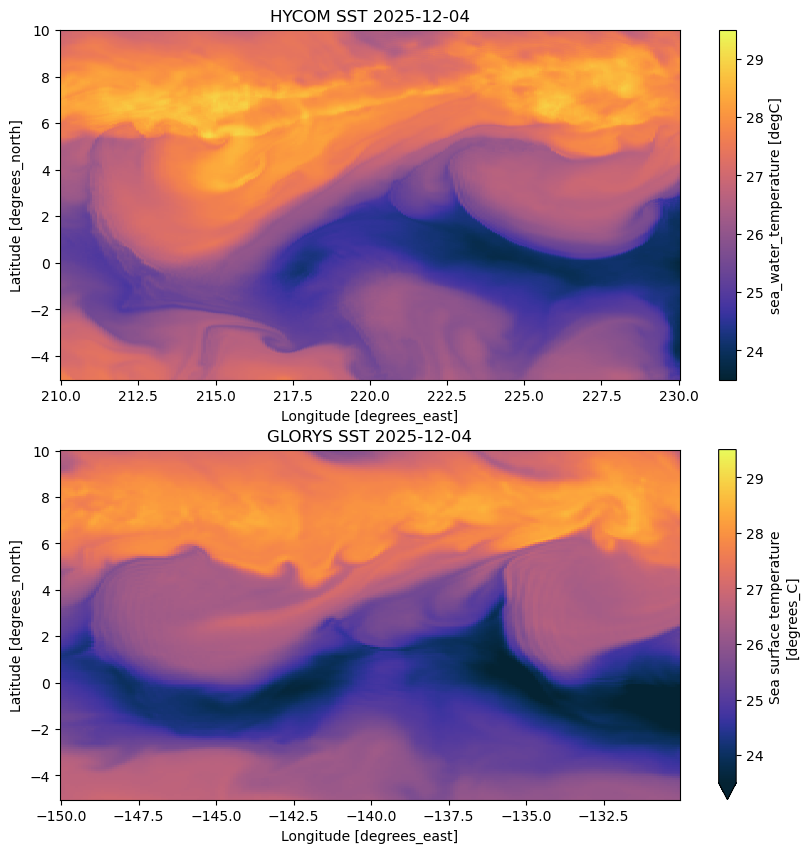

In [28]:
date_str = '2025-12-04'
fig, ax = plt.subplots(figsize=(10,10),nrows=2)
ds_hycom.sst.sel(time=np.datetime64(date_str)).plot(ax=ax[0],cmap=cmo.thermal, vmin=23.5, vmax=29.5)
ax[0].set_title('HYCOM SST ' + date_str)
ds_glorys.thetao.sel(time=np.datetime64(date_str)).plot(ax=ax[1],cmap=cmo.thermal, vmin=23.5, vmax=29.5)
ax[1].set_title('GLORYS SST ' + date_str)

# diff = ds_hycom.sst.sel(time=np.datetime64(date_str)).values - ds_glorys.thetao.sel(time=np.datetime64(date_str)).values
# temp = ds_hycom.sst.sel(time=np.datetime64(date_str)).copy(deep=True)
# temp.values = diff
# diff = temp
# diff.plot(ax=ax[2],cmap='bwr', vmin=-2, vmax=2)